In [1]:
# imports
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster,dendrogram
from tslearn.metrics import cdist_dtw
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Right eye cluster analysis

In [2]:
# Load data
df_full_right = pd.read_excel("../Pupilometri/Right_manually_cleaned_artefacts.xlsx", sheet_name=0)
# Create list of rows to skip: 0–8 (This is all metadata)
skip_rows = list(range(0, 8))
df = pd.read_excel("../Pupilometri/Right_manually_cleaned_artefacts.xlsx", sheet_name=0,skiprows=skip_rows)
df = df.dropna(axis=1)


In [3]:
df_long = df.melt(
    id_vars="Time",
    var_name="record_id",
    value_name="Pupil_Diameter"
)


In [4]:
# Transpose for clustering (rows = patients, cols = time points)
X = df.iloc[:, 1:].T.values  
record_ids = df.columns[1:]

### DTW + hierarchical clustering


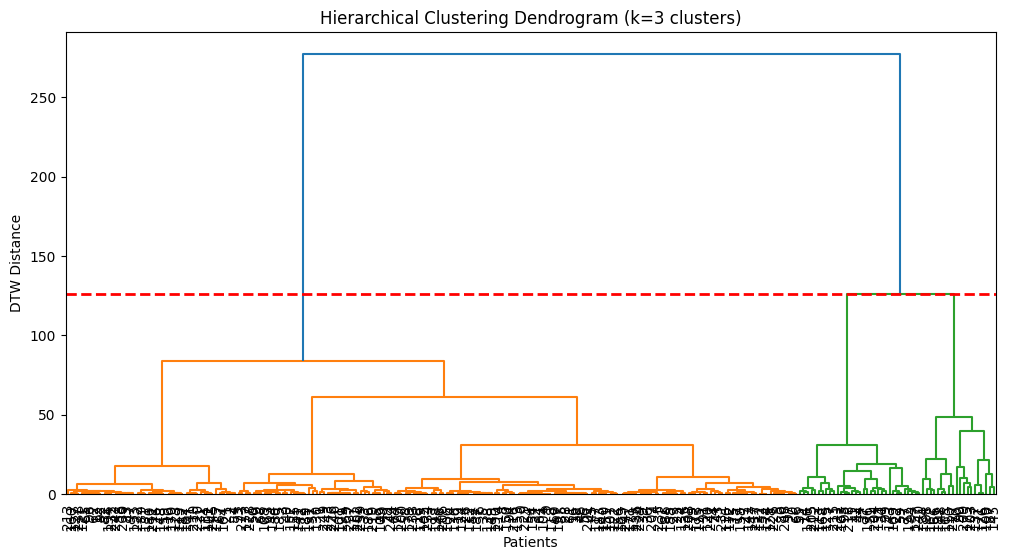

In [5]:
# Compute pairwise DTW distances
D = cdist_dtw(X) 

# Hierarchical clustering with Ward linkage
Z = linkage(D[np.triu_indices(len(D), k=1)], method="ward")

plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    labels=None,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=0.5*max(Z[:,2]),     
)

# Draw horizontal line to show cut for 3 clusters
plt.axhline(y=Z[-(3-1), 2], c='red', linestyle='--', lw=2)
plt.title(f"Hierarchical Clustering Dendrogram (k={3} clusters)")
plt.xlabel("Patients")
plt.ylabel("DTW Distance")
plt.show()


In [ ]:

k = 3  # number of clusters
clusters_hc = fcluster(Z, t=k, criterion="maxclust")

# Store the cluster in DataFrame
df_clusters = pd.DataFrame({
    "record_id": record_ids,
    "Cluster_HC": clusters_hc
})

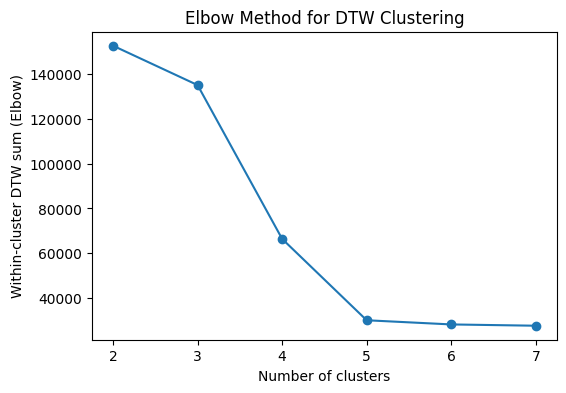

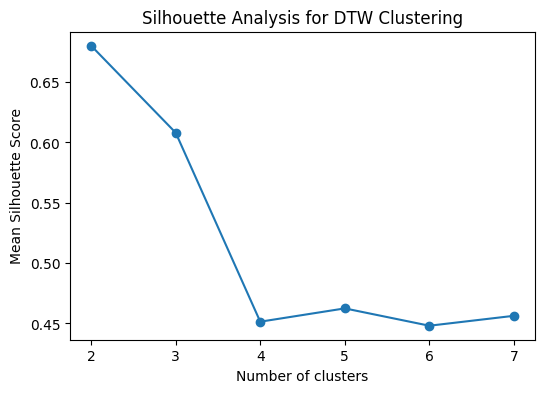

In [7]:
max_clusters = 7
inertia = []
sil_scores = []

for k in range(2, max_clusters + 1):
    labels = fcluster(Z, k, criterion='maxclust')
    
    wcss = 0
    for cluster_id in np.unique(labels):
        cluster_idx = np.where(labels == cluster_id)[0]
        cluster_dist = D[np.ix_(cluster_idx, cluster_idx)]
        wcss += np.sum(np.triu(cluster_dist, 1))
    inertia.append(wcss)
    
    # Mean silhouette score
    score = silhouette_score(D, labels, metric='precomputed')
    sil_scores.append(score)

# Plot Elbow 
plt.figure(figsize=(6, 4))
plt.plot(range(2, max_clusters + 1), inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Within-cluster DTW sum (Elbow)")
plt.title("Elbow Method for DTW Clustering")
plt.show()

# Plot mean Silhouette 
plt.figure(figsize=(6, 4))
plt.plot(range(2, max_clusters + 1), sil_scores, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Mean Silhouette Score")
plt.title("Silhouette Analysis for DTW Clustering")
plt.show()



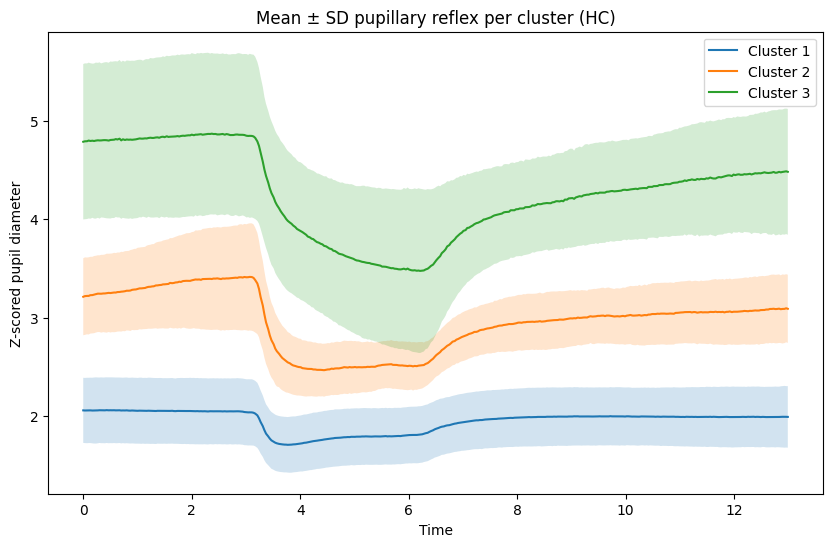

In [8]:
# Merge hierarchical clusters
data_long = df_long.merge(df_clusters[["record_id", "Cluster_HC"]], on="record_id")
summary = data_long.groupby(["Time", "Cluster_HC"]).agg(
    Mean=("Pupil_Diameter", "mean"),
    SD=("Pupil_Diameter", "std")
).reset_index()

plt.figure(figsize=(10, 6))
for cluster in summary["Cluster_HC"].unique():
    sub = summary[summary["Cluster_HC"] == cluster]
    plt.plot(sub["Time"], sub["Mean"], label=f"Cluster {cluster}")
    plt.fill_between(sub["Time"],
                     sub["Mean"] - sub["SD"],
                     sub["Mean"] + sub["SD"],
                     alpha=0.2)
plt.legend()
plt.title("Mean ± SD pupillary reflex per cluster (HC)")
plt.xlabel("Time")
plt.ylabel("Z-scored pupil diameter")
plt.show()


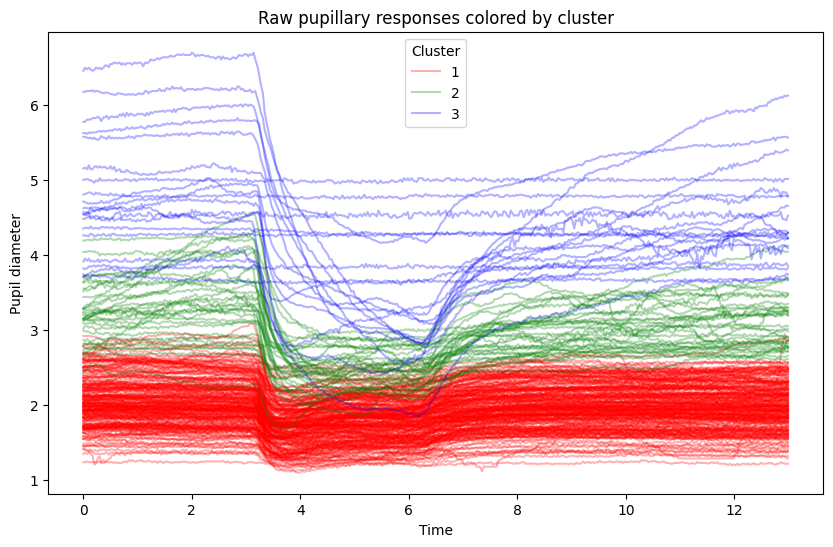

In [9]:

# Plot raw data colored by cluster
palette = {1: "red", 2: "green", 3: "blue"}
plt.figure(figsize=(10,6))
sns.lineplot(
    data=data_long,
    x="Time",
    y="Pupil_Diameter",
    hue="Cluster_HC",
    palette=palette,
    units="record_id",
    estimator=None,
    alpha=0.3
)
plt.title("Raw pupillary responses colored by cluster")
plt.ylabel("Pupil diameter")
plt.xlabel("Time")
plt.legend(title="Cluster")
plt.show()


In [10]:
df_clusters["Cluster_HC"].value_counts()


Cluster_HC
1    197
2     33
3     20
Name: count, dtype: int64

In [11]:
df_clusters['Cluster_HC'] = df_clusters['Cluster_HC'].map({
    1: 'Low',
    2: 'Medium',
    3: 'High'
})


In [12]:
Full_t= df_full_right.T
Full_t.columns = Full_t.iloc[0]  # set first row as header
Full_t = Full_t[1:]               # remove the first row from the data
Full_t.rename(columns={"Time": "record_id"}, inplace=True)



In [13]:
df_merged = Full_t.merge(
    df_clusters[['record_id', 'Cluster_HC']],
    on='record_id',
    how='left'  # keeps all original rows
)

#### Does cluster seperate different metdata?

In [14]:
# Survival
counts = df_merged.pivot_table(
    index="Cluster_HC",
    columns="90-day survival",
    aggfunc="size",
    fill_value=0
)
#print(counts)
percent = counts.div(counts.sum(axis=1), axis=0) * 100
print(percent)


90-day survival          N          Y
Cluster_HC                           
High             70.588235  29.411765
Low              43.930636  56.069364
Medium           44.444444  55.555556


In [15]:
# Outcome at ICU
counts = df_merged.pivot_table(
    index="Cluster_HC",
    columns="Outcome at ICU",
    aggfunc="size",
    fill_value=0
)
# print(counts)
percent = counts.div(counts.sum(axis=1), axis=0) * 100
print(percent)

Outcome at ICU          A          D
Cluster_HC                          
High            41.176471  58.823529
Low             66.473988  33.526012
Medium          62.962963  37.037037


In [16]:
# SECONDS
counts = df_merged.pivot_table(
    index="Cluster_HC",
    columns="SECONDS",
    aggfunc="size",
    fill_value=0
)
# print(counts)
percent = counts.div(counts.sum(axis=1), axis=0) * 100
print(percent)

SECONDS             C         E        M+         M-          U
Cluster_HC                                                     
High        65.000000  0.000000  0.000000  10.000000  25.000000
Low         84.771574  0.507614  1.015228   2.030457  11.675127
Medium      51.515152  0.000000  3.030303  24.242424  21.212121


# K-means (To see if they cluster differently) (1 and 3 is changed from K-means to DTW)

In [17]:
# Simple KMeans on standardized time series (Euclidean)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters_kmeans = kmeans.fit_predict(X)

df_clusters["Cluster_KMeans"] = clusters_kmeans + 1


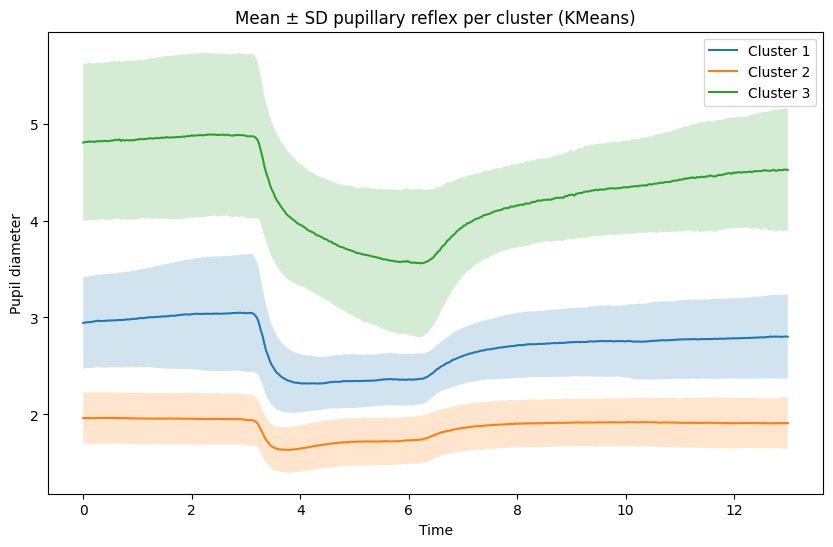

In [18]:
# Merge hierarchical clusters
data_long = df_long.merge(df_clusters[["record_id", "Cluster_KMeans"]], on="record_id")
summary = data_long.groupby(["Time", "Cluster_KMeans"]).agg(
    Mean=("Pupil_Diameter", "mean"),
    SD=("Pupil_Diameter", "std")
).reset_index()

plt.figure(figsize=(10, 6))
for cluster in summary["Cluster_KMeans"].unique():
    sub = summary[summary["Cluster_KMeans"] == cluster]
    plt.plot(sub["Time"], sub["Mean"], label=f"Cluster {cluster}")
    plt.fill_between(sub["Time"],
                     sub["Mean"] - sub["SD"],
                     sub["Mean"] + sub["SD"],
                     alpha=0.2)
plt.legend()
plt.title("Mean ± SD pupillary reflex per cluster (KMeans)")
plt.xlabel("Time")
plt.ylabel("Pupil diameter")
plt.show()


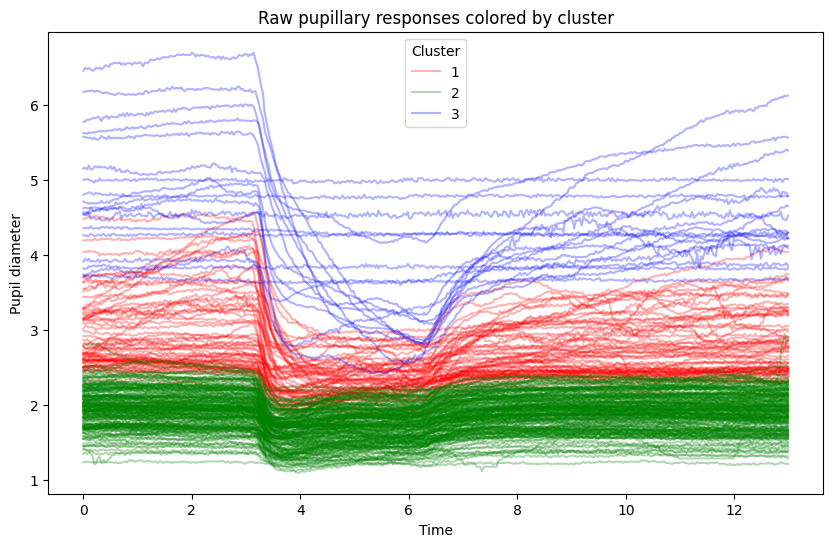

In [19]:
# Plot raw data colored by cluster
palette = {1: "red", 2: "green", 3: "blue"}
plt.figure(figsize=(10,6))
sns.lineplot(
    data=data_long,
    x="Time",
    y="Pupil_Diameter",
    hue="Cluster_KMeans",
    palette=palette,
    units="record_id",
    estimator=None,
    alpha=0.3
)
plt.title("Raw pupillary responses colored by cluster")
plt.ylabel("Pupil diameter")
plt.xlabel("Time")
plt.legend(title="Cluster")
plt.show()


In [20]:
df_clusters["Cluster_KMeans"].value_counts()


Cluster_KMeans
2    168
1     63
3     19
Name: count, dtype: int64

In [21]:
df_clusters['Cluster_KMeans'] = df_clusters['Cluster_KMeans'].map({
    1: 'Medium',
    2: 'Low',
    3: 'High'
})


In [22]:
df_clusters.to_csv("../Modified_Pupilometri/Cluster_right.csv")

In [23]:
len(df_clusters[df_clusters['Cluster_KMeans'] != df_clusters['Cluster_HC']])

30

# Add controls


In [24]:
df = pd.read_excel("../Pupilometri/Right_manually_cleaned_artefacts.xlsx", sheet_name=0,skiprows=8)
df = df.dropna(axis=1)
df_control = pd.read_excel("../Pupilometri/healthy_controls_right_visual.xlsx", sheet_name=0,skiprows=2)

df = pd.concat([df, df_control], axis=1)
df = df.loc[:, ~df.columns.duplicated()]



In [25]:
# Transpose for clustering (rows = patients & controls, cols = time points)
X = df.iloc[:, 1:].T.values  
record_ids = df.columns[1:]

In [26]:
# Same as before, with added controls

# Compute pairwise DTW distances
D = cdist_dtw(X) 

# Hierarchical clustering with Ward linkage
Z = linkage(D[np.triu_indices(len(D), k=1)], method="ward")
k = 3  # number of clusters
clusters_hc = fcluster(Z, t=k, criterion="maxclust")

# Store in DataFrame
df_clusters = pd.DataFrame({
    "record_id": record_ids,
    "Cluster_HC": clusters_hc
})


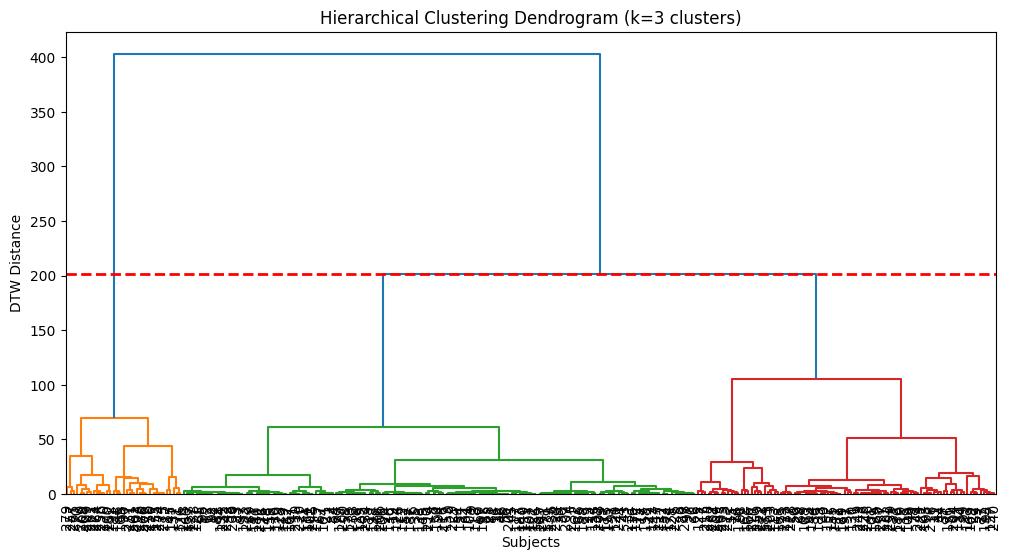

In [27]:
plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    labels=None,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=0.3*max(Z[:,2]),     
)

# Draw horizontal line to show cut for 3 clusters
plt.axhline(y=Z[-(k-1), 2], c='red', linestyle='--', lw=2)
plt.title(f"Hierarchical Clustering Dendrogram (k={k} clusters)")
plt.xlabel("Subjects")
plt.ylabel("DTW Distance")
plt.show()


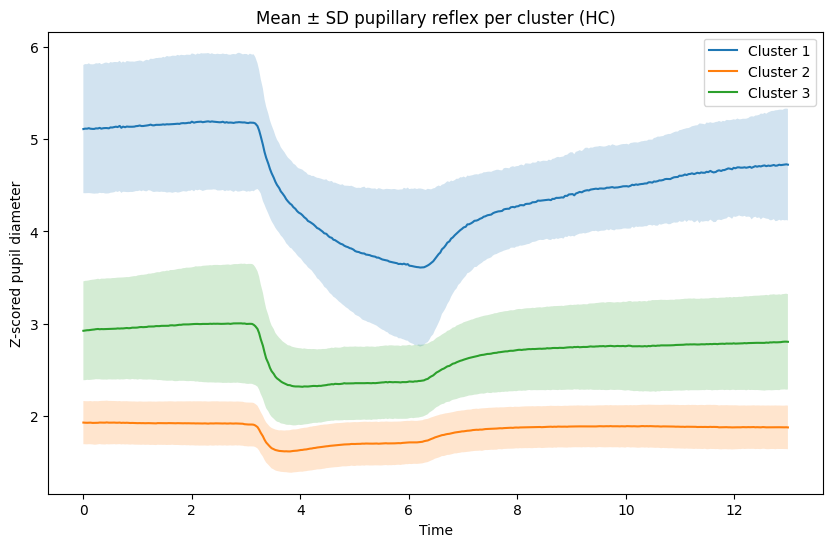

In [28]:
# Merge hierarchical clusters
data_long = df_long.merge(df_clusters[["record_id", "Cluster_HC"]], on="record_id")
summary = data_long.groupby(["Time", "Cluster_HC"]).agg(
    Mean=("Pupil_Diameter", "mean"),
    SD=("Pupil_Diameter", "std")
).reset_index()

plt.figure(figsize=(10, 6))
for cluster in summary["Cluster_HC"].unique():
    sub = summary[summary["Cluster_HC"] == cluster]
    plt.plot(sub["Time"], sub["Mean"], label=f"Cluster {cluster}")
    plt.fill_between(sub["Time"],
                     sub["Mean"] - sub["SD"],
                     sub["Mean"] + sub["SD"],
                     alpha=0.2)
plt.legend()
plt.title("Mean ± SD pupillary reflex per cluster (HC)")
plt.xlabel("Time")
plt.ylabel("Z-scored pupil diameter")
plt.show()


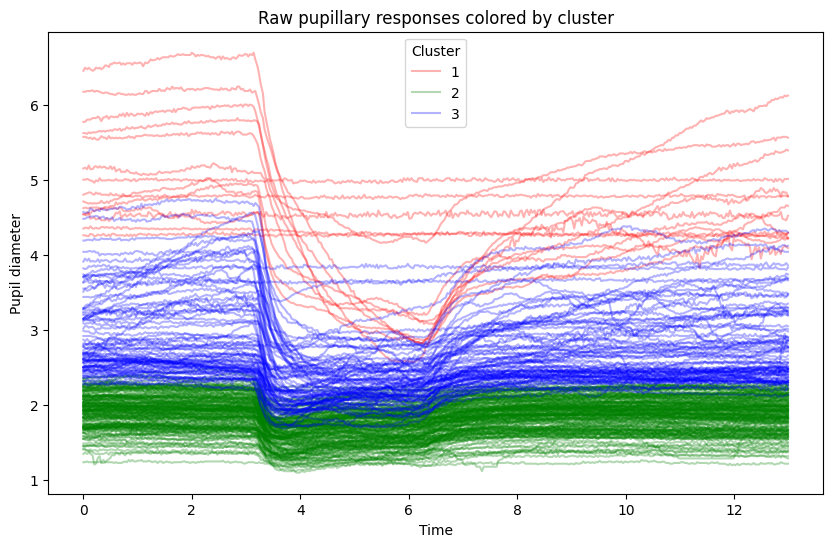

In [29]:

# Plot raw data colored by cluster
palette = {1: "red", 2: "green", 3: "blue"}
plt.figure(figsize=(10,6))
sns.lineplot(
    data=data_long,
    x="Time",
    y="Pupil_Diameter",
    hue="Cluster_HC",
    palette=palette,
    units="record_id",
    estimator=None,
    alpha=0.3
)
plt.title("Raw pupillary responses colored by cluster")
plt.ylabel("Pupil diameter")
plt.xlabel("Time")
plt.legend(title="Cluster")
plt.show()


In [30]:
df_clusters["Cluster_HC"].value_counts()


Cluster_HC
2    155
3     90
1     35
Name: count, dtype: int64

In [31]:
# The cluster the healthy controls were assigned to
#df_clusters.tail(30)
